Наша модель умеет генерировать текст. В модуле 15 мы научились этим текстом управлять: температура, top-k, top-p. Кажется, что до ChatGPT остался один шаг. Давайте проверим - просто спросим её о чём-нибудь.

**Задаём вопрос**

Модель обучена на рассказе про кота Барсика. Значит, имя кота она точно знает. Спрашиваем:

`
Question: What is the cat name?
Answer:`

                  
И получаем:

`to bed. I slept soundly. The cat was dreaming.
In the dream, the cat`

                  
Не ответ, а обрывок рассказа. Модель не поняла, что у неё что-то спросили.

Всё обучение сводилось к одному вопросу: «какое слово идёт дальше?» Мы дали ей рассказ, она выучила, какие слова в нём за какими следуют.

Теперь мы подсовываем ей строку «Question: What is the cat name? Answer:» и ждём осмысленного ответа. А модель делает ровно то, чему училась: подбирает продолжение. Для неё это не вопрос, а просто текст, который надо чем-то продолжить.

Знания у неё есть. Имя Барсика лежит в весах, мы его туда положили. Не хватает другого - отвечать на вопрос.

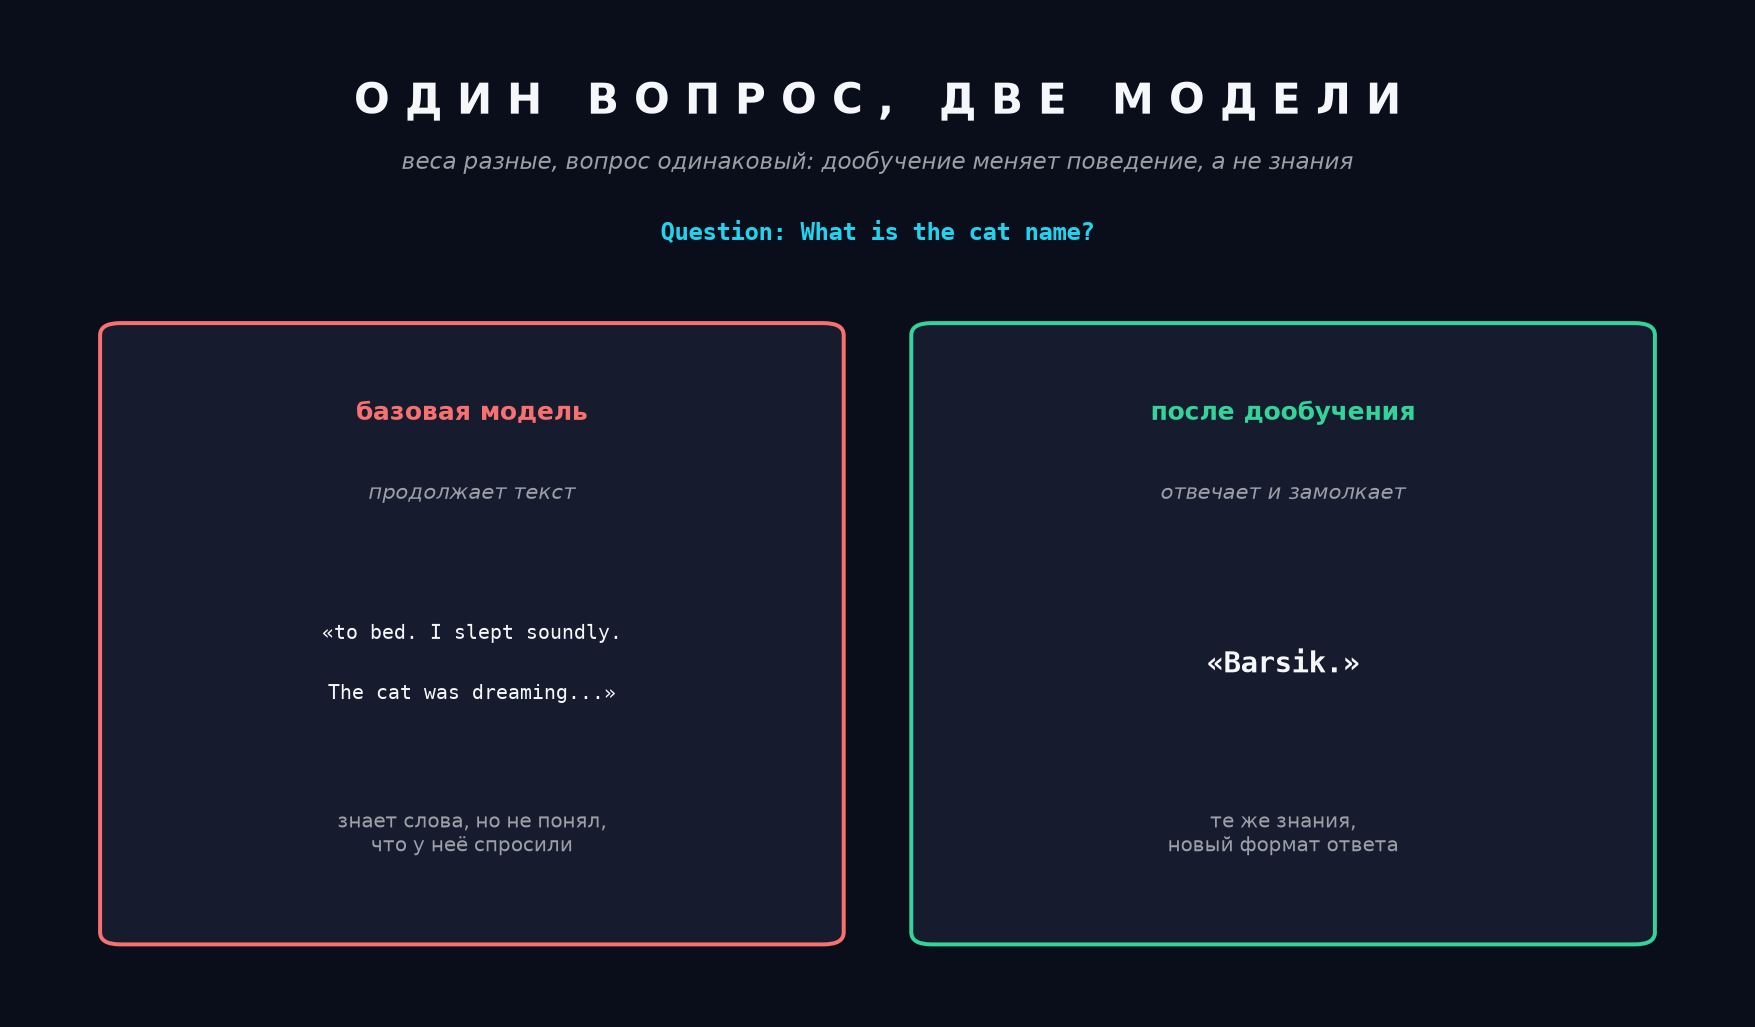

С GPT-3 в 2020 году была та же история. Модель гигантская, знает половину интернета, а вести диалог не умеет: продолжает текст, и всё. Чтобы получился ChatGPT, OpenAI сделала отдельный шаг - дообучила базовую модель на примерах «запрос - хороший ответ». Эта работа известна как InstructGPT, и именно она превратила языковую модель в собеседника.

Тем же займёмся и мы. Модель уже знает язык. Осталось показать ей, как себя вести.

Архитектуру не трогаем совсем. Ни одного нового слоя, ни одной новой формулы внимания. Меняется только то, на каких примерах и как мы считаем ошибку!

**Fine-tuning (дообучение)** - это когда берут уже обученную модель и доучивают её на новых примерах, не начиная с нуля.

Ключевое слово здесь «уже обученную». Мы не создаём модель заново и не трогаем архитектуру. Мы берём те самые веса, которые получились после `train.py`, и аккуратно их подправляем.

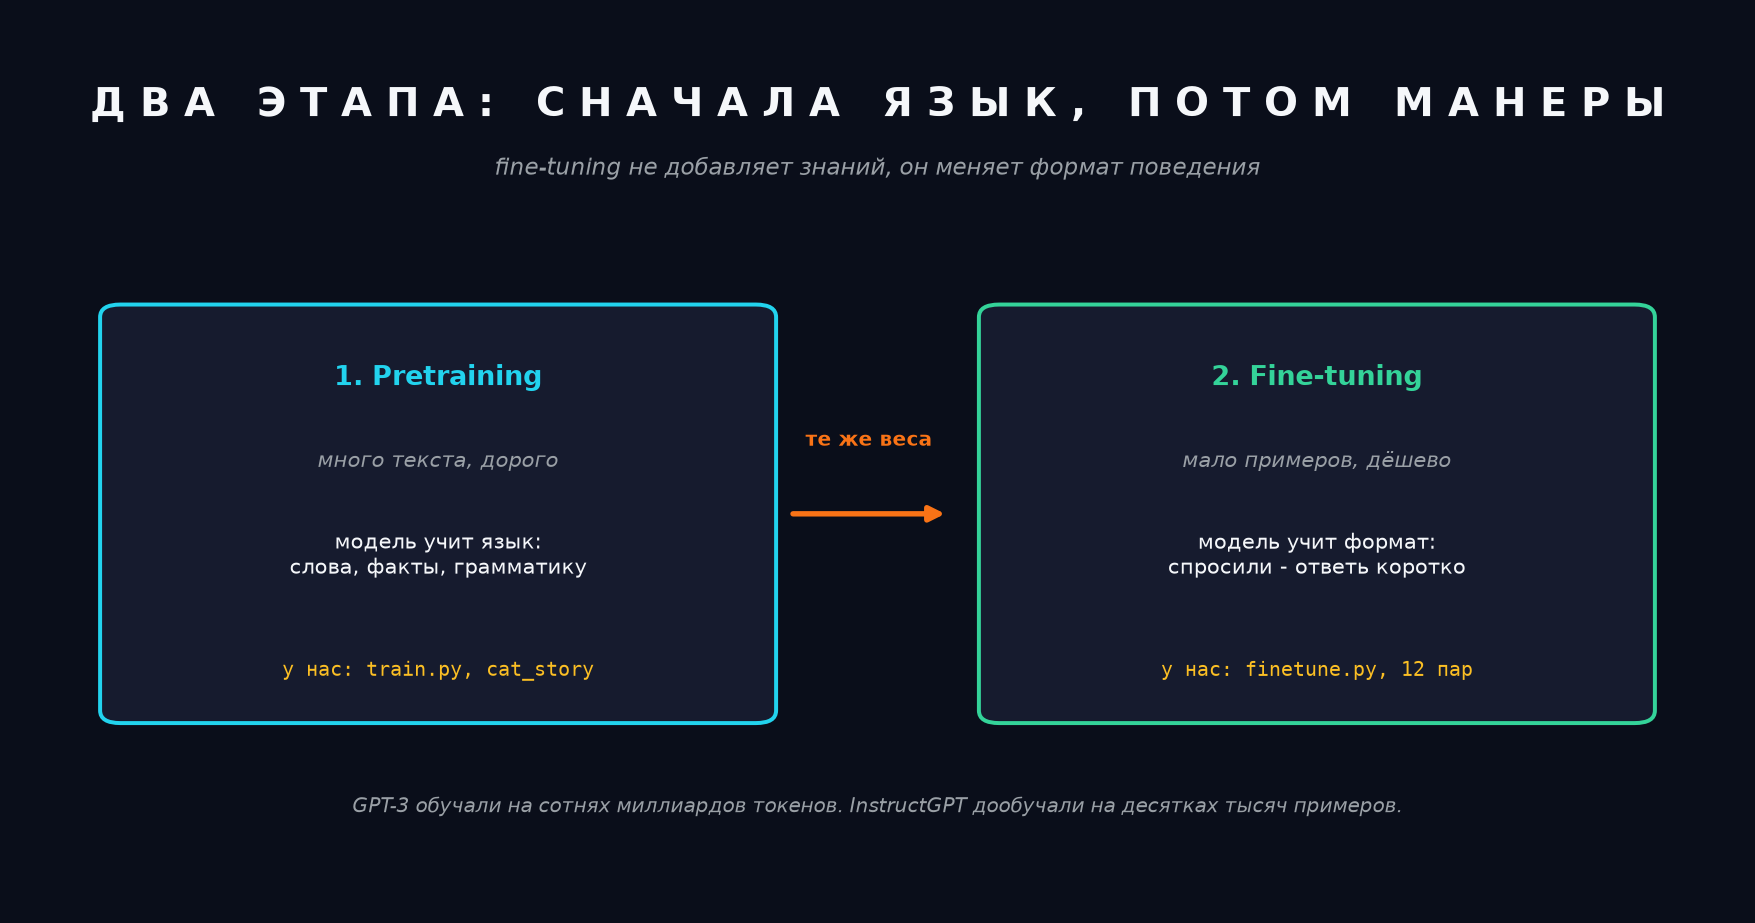

**Этап 1, pretraining.** Модель читает много текста и учится предсказывать следующий токен. Отсюда берутся язык, факты и грамматика. Это долго и дорого: GPT-3 обучали на сотнях миллиардов токенов. У нас этот этап уже позади - train.py и рассказ про Барсика.

**Этап 2, fine-tuning.** Модель видит небольшой набор примеров нужного формата и подстраивает под него поведение. Здесь хватает тысяч примеров вместо миллиардов, а времени уходит не недели, а минуты.



**Дообучение не добавляет знаний**


Частое заблуждение: раз мы дообучаем модель на своих данных, она «выучит» новую информацию. На маленьком наборе примеров - почти нет.

Наши 12 ответов взяты из рассказа, который модель уже читала. Мы не сообщаем ей ничего нового про Барсика. Мы показываем ей форму поведения: если пришёл вопрос, дай короткий ответ и остановись.

Хотите, чтобы модель знала свежие факты, - есть два пути. Либо кладите их прямо в промпт (так работает RAG: сначала находим нужный кусок текста, потом отдаём его модели вместе с вопросом), либо возвращайтесь к полноценному обучению на большом корпусе. Дообучение на десятке примеров для этого не годится.

Мы сделаем самый простой и самый распространённый вариант.

`SFT` (supervised fine-tuning) - обучение на готовых парах «запрос - правильный ответ». Человек написал, каким должен быть ответ, модель учится его повторять. Этим мы и займёмся.

`RLHF` и `DPO` - следующий уровень. Здесь модели показывают не один правильный ответ, а два варианта, и человек отмечает, какой лучше. Модель учится на предпочтениях. Так ChatGPT научили быть вежливым, отказываться от опасных просьб и выбирать из двух правильных ответов тот, что понятнее. Реализовывать это мы не будем: нужен отдельный курс и разметчики.

`LoRA` - способ дообучать дёшево. Вместо того чтобы менять все веса модели, к ней добавляют маленькие матрицы-надстройки и учат только их. Для модели на семь миллиардов параметров это разница между дата-центром и одной видеокартой. Нашу модель на шесть миллионов параметров можно дообучить целиком, поэтому LoRA нам не нужна.

Что меняется в коде
Почти ничего. Тот же SimpleLLM, тот же cross_entropy, тот же Adam. Отличий будет три:

- веса берём из best_model.pth, а не создаём случайные;
- learning rate меньше: модель уже умеет говорить, её нужно подправить, а не переучить;
- данные не сплошной текст, а пары «вопрос - ответ», и loss мы считаем только по ответу.


Последний пункт - самый интересный, ему посвящён отдельный урок. Но сначала разберёмся, как вообще выглядят данные для дообучения.

Для обучения с нуля нам хватало сплошного текста: берём рассказ, режем скользящим окном, учим предсказывать следующий токен. Для дообучения нужны пары «вопрос - ответ». Каждая пара - отдельный обучающий пример.

**Шаблон промпта**

Модель не знает, где заканчивается вопрос и начинается ответ. Мы должны показать это разметкой:

`Question: What is the cat name?`


`Answer: Barsik.`

Слова Question: и Answer: - обычные токены, никакой магии в них нет. Но если во всех примерах они стоят на одних и тех же местах, модель быстро улавливает закономерность: после Answer: идёт короткая фраза по делу.

**Формат должен быть одинаковым и на обучении, и потом в разговоре. Если обучали с переносом строки перед Answer:, а спрашивать станете без него, качество просядет: для модели это будет другой текст. Поэтому шаблон стоит завести один раз и держать в коде отдельной строкой:**

`PROMPT_TEMPLATE = "Question: {question}\nAnswer:"`

У настоящих моделей та же идея, только шаблоны сложнее. У них есть служебные токены ролей вроде `<|user|>` и `<|assistant|>`, и разметка отделяет реплики собеседников друг от друга. Суть та же: показать модели структуру диалога.

Ответы берём из рассказа про Барсика, почти дословно:

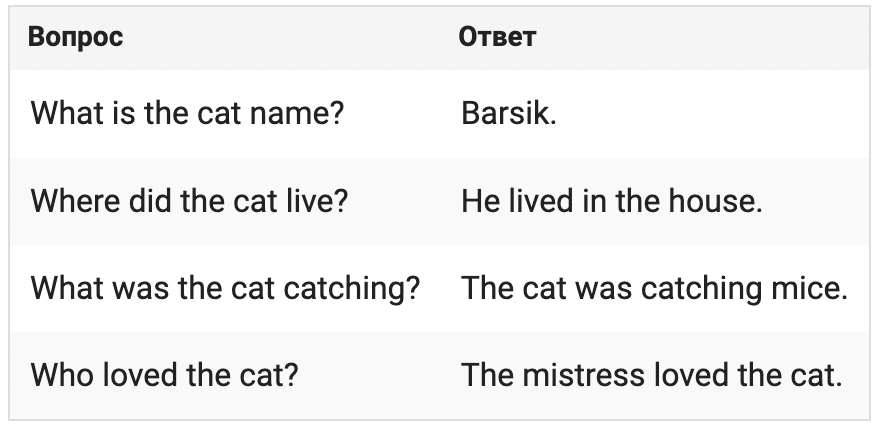

Всего таких пар у нас будет 12. Это простой выбор: ответы должны опираться на то, что модель уже читала. Спросите её про собаку - и она начнёт выдумывать, потому что собаки в рассказе не было.

Ещё одно правило: ответы короткие и однотипные. Модель учится не только содержанию, но и длине. Если половина ответов в одно слово, а половина на три строки, она будет метаться между двумя манерами.

Тут появляется проблема, которой не было в генерации текста. Раньше мы просто просили 20 токенов и получали 20 токенов. В диалоге так нельзя: ответ «Barsik.» занимает три токена, а не двадцать.

Модель должна сама сказать, что закончила. Для этого в конец каждого ответа при обучении ставят специальный токен конца текста:

`Question: What is the cat name?`

`Answer: Barsik.<|endoftext|>`

У токенизатора GPT-2 это `<|endoftext|>` с номером 50256, его же зовут EOS (end of sequence). Модель видит его в конце каждого примера и запоминает: после точки в ответе идёт вот этот токен.

А при генерации мы просто следим за выходом. Выпал EOS - останавливаемся и не печатаем его. Получается ответ ровно той длины, которую выбрала сама модель.

Тот же механизм работает в любом чат-боте. Когда ChatGPT заканчивает ответ, он не упирается в лимит символов - он генерирует свой служебный токен остановки.

Один обучающий пример целиком выглядит так:

`Question: What is the cat name?`

`Answer: Barsik.<|endoftext|>`

Вопрос, ответ, сигнал остановки. Дальше нужно объяснить модели, за какую часть этой строки с неё спрашивают. Этим займёмся в следующем уроке.

Обучающий пример готов: вопрос, ответ, EOS в конце. Осталось решить, за что именно спрашивать с модели.

Если подать всю строку так же, как мы подавали рассказ, модель начнёт учиться предсказывать каждый токен подряд. В том числе токены вопроса.

Звучит безобидно, но подумайте, чему она при этом научится. Увидев «Question: What is the», она будет старательно угадывать, что дальше идёт «cat». То есть учиться сочинять вопросы. А нам нужно ровно обратное: вопрос модель получает готовым от пользователя, придумывать его не надо никогда.

Хуже того, вопросов в наших данных ровно столько же, сколько ответов. Половина усилий обучения уйдёт на бесполезный навык.

**Решение: закрыть промпт маской**

Модель по-прежнему читает весь пример целиком, иначе она не поймёт, на что отвечает. Но учится только на ответе.

Технически это делается меткой -100. Для каждой позиции мы говорим, какой токен там должен быть, а вместо токенов вопроса ставим -100:

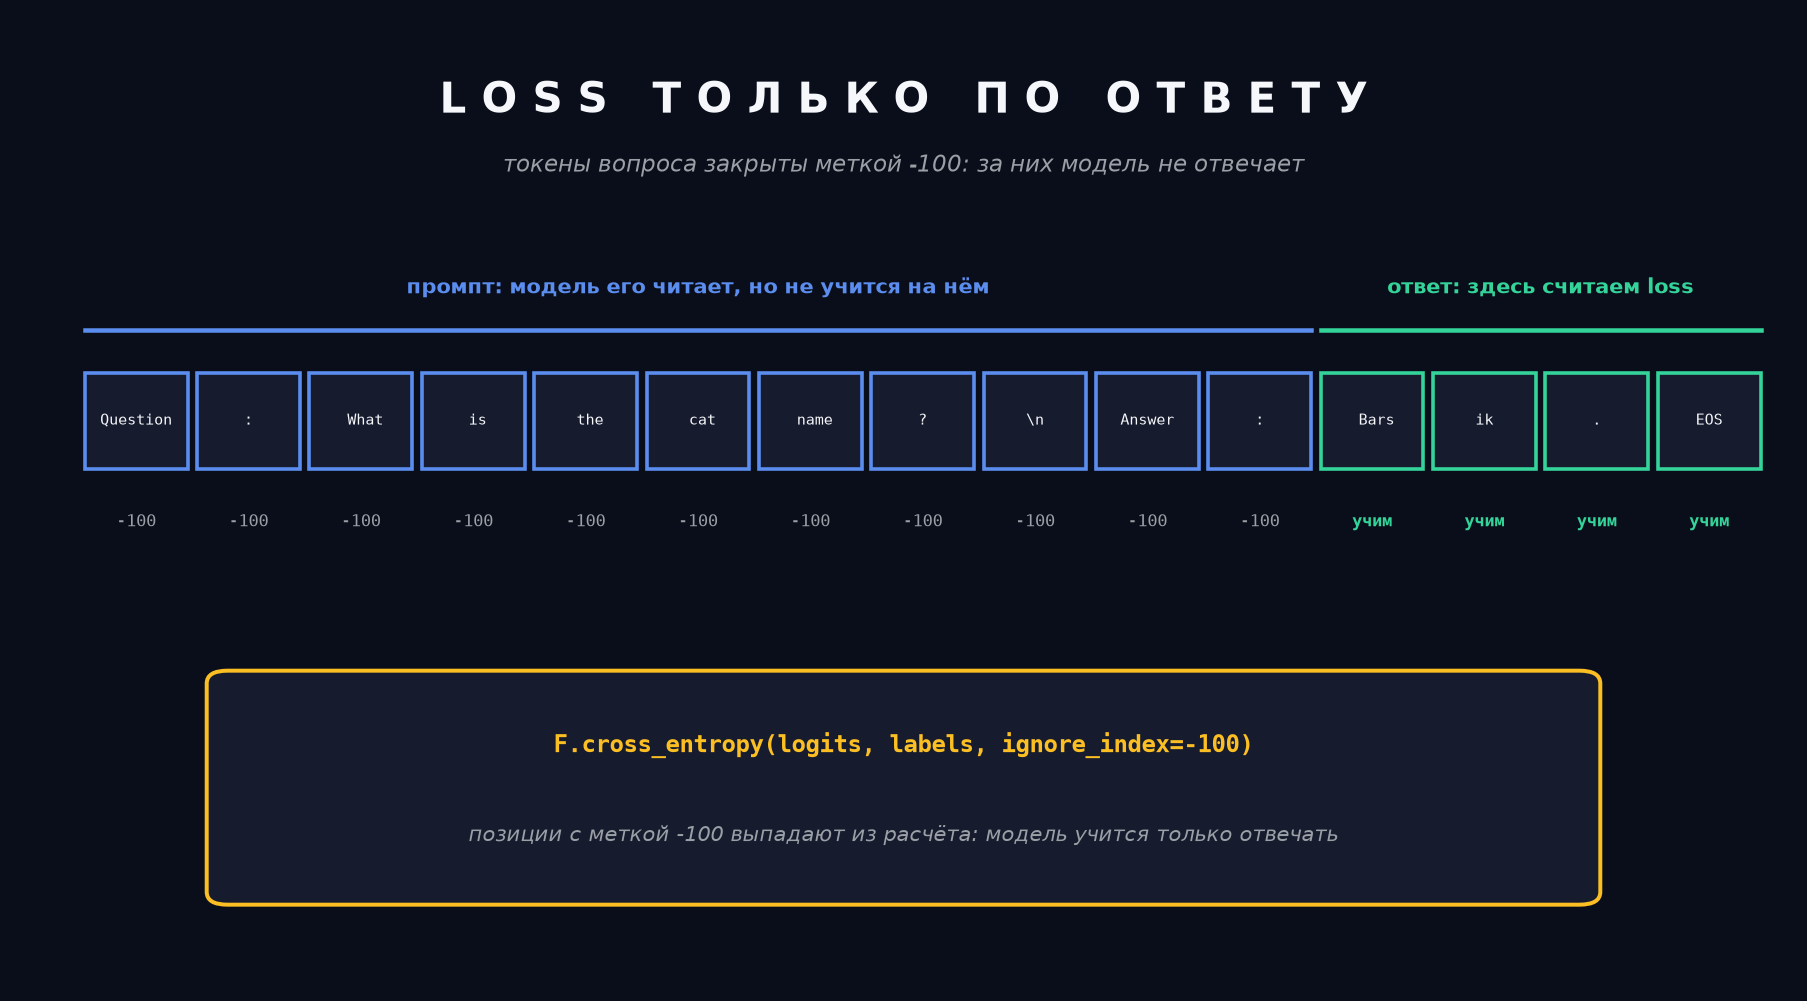

Функция cross_entropy знает про этот код и умеет его пропускать:

`loss = F.cross_entropy(logits, labels, ignore_index=-100)`

                  
Позиции с меткой `-100` просто выпадают из расчёта. Ни ошибки, ни градиента, ни обновления весов из-за них не будет. Число `-100` выбрано потому, что настоящим номером токена оно быть не может: индексы в словаре всегда неотрицательные.

Вот как наш первый пример выглядит внутри датасета. Слева токен, справа метка, по которой считается ошибка:

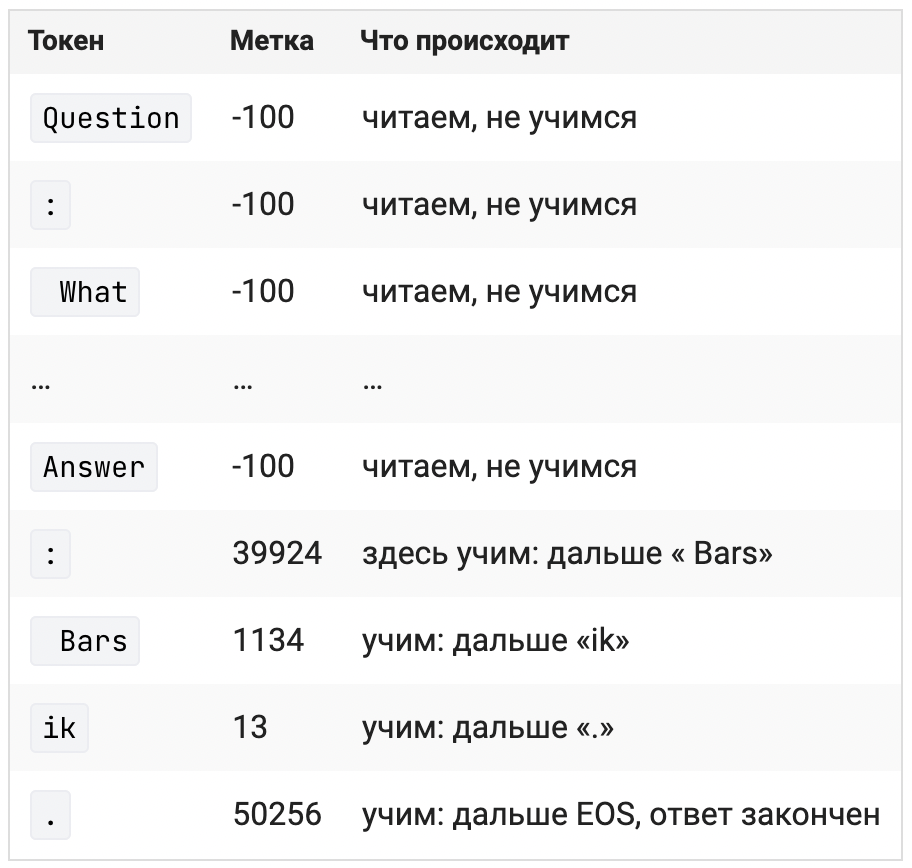

Обратите внимание на строку с двоеточием после `Answer`. Метка там уже не `-100`: именно в этой позиции модель впервые должна выдать что-то своё. Промпт закончился, начинается работа.

И последняя строка не менее важна. На токене «.» модель учится предсказывать EOS. Так она и запоминает, где заканчивать.


Но что будет, если маску не ставить? Модель всё равно чему-то научится, и ответы даже станут похожи на правильные. Но вместе с ними она будет уверенно продолжать за вас вопросы, а короткие ответы начнёт разбавлять лишним текстом. На 12 примерах разница видна не сразу, на реальных данных она заметная.

Маска промпта - стандарт для всех SFT-пайплайнов. В библиотеках вроде TRL от Hugging Face она включена по умолчанию, там это называется completion-only loss.

Возьмём наш обучающий пример и посмотрим, сколько в нём токенов:

`>>> from tokenizer_utils import get_tokenizer`

`>>> tokenizer = get_tokenizer()`

`>>> text = "Question: What is the cat name?\nAnswer: Barsik."`

`>>> len(tokenizer.encode(text))`

`14`

Четырнадцать. А в config.py у нас с шестого модуля стоит:

`max_length: int = 4`

Четыре токена. В окно помещается «Question: What is», и на этом всё заканчивается.

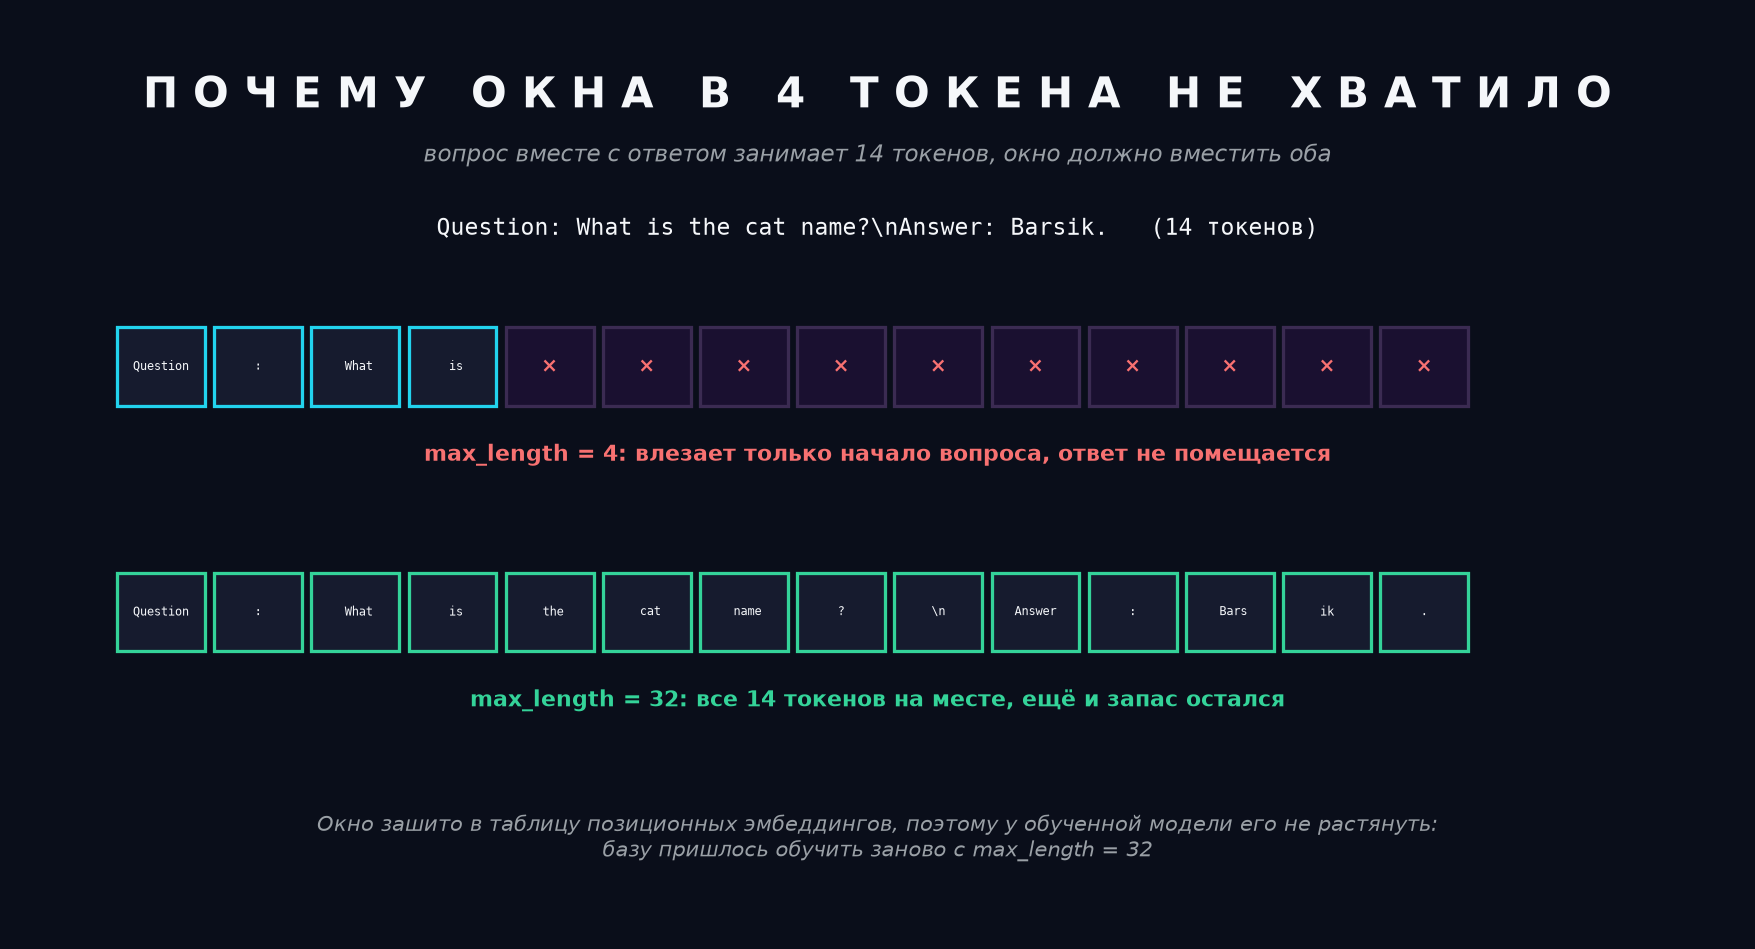

Для дообучения это приговор. Модель должна увидеть вопрос и ответ одновременно, иначе связь между ними не выучить. С окном в четыре токена ответ до неё просто не доедет.



**Почему нельзя просто поменять число?**

Первая мысль: поставить `max_length = 32`, загрузить `best_model.pth` и дообучать. Не выйдет, и вот почему.

Вспомните позиционное кодирование из модуля 7. У модели есть таблица позиционных эмбеддингов, по строке на каждую позицию в окне:

`self.position_embedding = nn.Embedding(max_seq_length, embed_dim)`

                  
При `max_seq_length = 4` в этой таблице ровно четыре строки. Модель знает, как выглядит первая позиция, вторая, третья и четвёртая. Про пятую она не знает ничего - для неё такой строки не существует.

Попробуете загрузить старые веса в модель с окном 32 - получите ошибку о несовпадении размеров. Обойдёте её - получите восемь необученных строк из тридцати двух, и модель начнёт путаться в позициях.

Поэтому базу придётся обучить заново. Хорошая новость: наш датасет крошечный, всё займёт пару минут.

Создадим файл `qa_data.py`.
Здесь всё простое, но пара мест заслуживает внимания.

`PROMPT_TEMPLATE` вынесен отдельной константой. Шаблон используется в трёх местах (датасет, дообучение, чат), и если он где-то разойдётся, модель начнёт отвечать хуже. Одна константа снимает этот риск.

`\n` перед `Answer`: - часть формата. Модель привыкает к переносу строки так же, как к самим словам.

Ответы короткие и построены одинаково. Модель учится и содержанию, и длине.


Теперь превратим пары в тензоры. Создадим файл `qa_dataset.py`

Тут пять шагов внутри цикла - вся суть дообучения. Разберём их.

**Шаг 1.** Кодируем по отдельности. Можно было закодировать всю строку разом, но тогда мы не узнаем, сколько токенов занял вопрос. А без этого не расставить маску.

**Шаг 2 и 3.** Вход и метки строятся из одних и тех же кусков, но по-разному: во входе промпт как есть, в метках на его месте -100. Модель прочитает вопрос, но отвечать за него не будет.

**Шаг 4.** Выравнивание. Примеры разной длины, а в батч нужны одинаковые. Добиваем короткие токеном EOS, а в метках на этих местах снова -100: учиться на пустом хвосте незачем.

**Шаг 5.** Сдвиг. Тот самый приём из модуля 13: по позиции i модель предсказывает то, что стоит на позиции i + 1.



Данные есть, пора дообучать. Создадим файл `finetune.py`.

Тут почти такой же цикл как в `train.py`: `forward`, `loss`, `zero_grad`, `backward`, `step`.

Только три отличия:
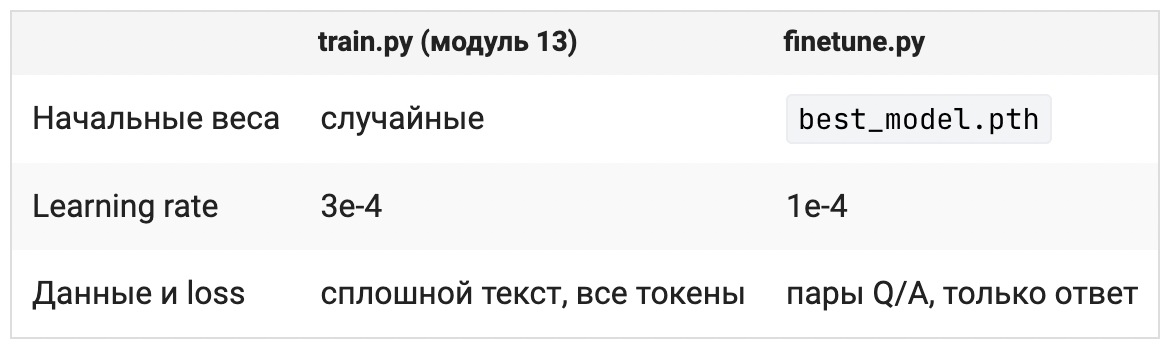


Про learning rate стоит сказать отдельно. У модели уже настроены веса, и большой шаг может их сломать: она забудет язык быстрее, чем выучит формат. У этой проблемы даже есть название - катастрофическое забывание. Маленький шаг двигает модель аккуратно.

В проекте теперь два файла с весами. `best_model.pth` - базовая модель, умеет продолжать текст. `chat_model.pth` - дообученная, должна уметь отвечать. Проверим это в следующем шаге.

Модель дообучена. Осталось с ней поговорить. Создадим файл `chat.py`

Функция `ask` - это `generate` из модуля 15 с двумя изменениями.

Первое: вопрос заворачивается в тот же шаблон, на котором мы обучались. Пользователь пишет `«What is the cat name?»`, а модель получает `«Question: What is the cat name?\nAnswer:»`. Про `build_prompt` мы позаботились заранее.



Второе, главное: цикл прерывается на EOS.

`if next_token.item() == tokenizer.eos_token_id:`

    break

Здесь `max_new_tokens` из главного параметра превратился в предохранитель. Обычно модель останавливается сама на третьем-шестом токене, а лимит нужен на случай, если она EOS не выдаст.

И вот, что мы получили:

Спросите модель о коте Барсике (пустая строка - выход).
Например: What is the cat name?

Вопрос: What is the cat name?
Ответ:  Barsik.

Вопрос: Where did the cat live?
Ответ:  He lived in the house.

Вопрос: Who loved the cat?
Ответ:  The mistress loved the cat.

Вопрос: 
Пока!

Создадим файл `demo_finetune.py`. Он загружает обе модели и задаёт им одинаковые вопросы.


Разберём по секциям.

**Секция 1.** Базовая модель на вопросы не отвечает, а продолжает рассказ с середины. Ровно то, с чего мы начинали модуль.

**Секция 2.** Те же вопросы, та же архитектура, другие веса - и три точных ответа. Дообучение сработало.

**Секция 3.** Хорошо видно, зачем нужен стоп по EOS. Модель ставит его сразу после ответа, но если её не слушать, она пойдёт дальше и начнёт городить обрывки других ответов. Токен остановки модель генерирует, а прекращать генерацию должен наш код.

**Секция 4.** Первый вопрос в обучающем наборе не встречался, но модель ответила разумно: поняла формат и подобрала подходящую фразу про кота. А вот второй ответ - неправда. Никакой собаки в рассказе не было, и правильно было бы сказать «не знаю». Вместо этого модель уверенно выдала «Barsik».

**Секция 5.** Здесь видно, насколько хрупкое у нас обобщение. «What is the name of the cat?» вместо «What is the cat name?» модель поняла и ответила верно. А на «Where does Barsik live?» вместо «Where did the cat live?» сбилась и выдала ответ от другого вопроса, про сон. Двенадцати примеров хватает, чтобы выучить формат, но мало, чтобы уверенно узнавать один и тот же вопрос в разных формулировках. Живые ассистенты и берут этим: у них таких примеров десятки тысяч.

Закрепим код тестами - файл `test_finetune.py`.

### Что у нас получилось и чего не получилось

- Модель отвечает на вопросы и вовремя останавливается. Для шести миллионов параметров и двенадцати примеров это хороший результат. Но давайте честно: до ChatGPT ей далеко, и полезно понимать, чего именно не хватает.

- Она выдумывает. Ответ про собаку тому пример. Модель не умеет говорить «не знаю»: её учили всегда что-то отвечать. Это и есть галлюцинации, та самая проблема, из-за которой ответам больших моделей нельзя верить на слово.

- Она помнит только двенадцать вопросов. Стоит переформулировать знакомый вопрос, и модель может ответить наугад - мы это видели в пятой секции демо. Настоящие ассистенты обучают на десятках и сотнях тысяч примеров, собранных живыми людьми. У InstructGPT разметчики писали ответы вручную месяцами.

- Она не ведёт диалог. Каждый вопрос модель видит с чистого листа: предыдущую реплику мы ей не передаём, да и окна в 32 токена на историю разговора не хватит.

- Её никто не учил выбирать между хорошим и плохим ответом. Мы показали по одному правильному ответу на вопрос. Следующий шаг в реальных системах - RLHF или DPO: там модели дают два варианта, человек отмечает лучший, и она учится на предпочтениях. Так модель становится вежливой и учится отказываться от опасных просьб.



В прошлом шаге мы увидели две слабости нашей модели. Она путается, если знакомый вопрос задать другими словами, и уверенно выдумывает ответ там, где ничего не знает. Обе лечатся, причём не архитектурой, а данными.

**Приём 1: несколько формулировок одного вопроса**

Модель запомнила ровно те двенадцать строк, которые видела. Спросите «Where does Barsik live?» вместо «Where did the cat live?» - для неё это другой текст, и она может ответить наугад.

Лечится добавлением вариантов. Один и тот же факт, разные формулировки вопроса, ответ одинаковый:

`("What is the cat name?",        "Barsik."),`

`("What is the name of the cat?", "Barsik."),`

Так модель учится связывать с ответом смысл вопроса, а не конкретный порядок слов. Приём называется аугментацией данных, и в реальных наборах для дообучения перефразировок бывает по несколько десятков на каждый случай.

**Приём 2: примеры отказа**

Наша модель никогда не видела примера, где правильный ответ - признать незнание. Все двенадцать обучающих пар выглядят так: спросили - ответил. Естественно, она отвечает всегда, даже про собаку, которой в рассказе не было.

Добавим пары, где ответ - отказ:

`("What is the dog name?",         "I do not know."),`

`("How old is the cat?",           "I do not know."),`

`("What is the capital of France?", "I do not know."),`

`("Do you like pizza?",           "I do not know."),`

Четыре примера, и поведение меняется целиком. Именно так учат настоящих ассистентов отвечать «не знаю» вместо выдумки.

Добавим эти примеры в массив и проверим работу.


Вопрос: What about dog?
Ответ:  I do not know.

Получилось!

Пройденный путь:
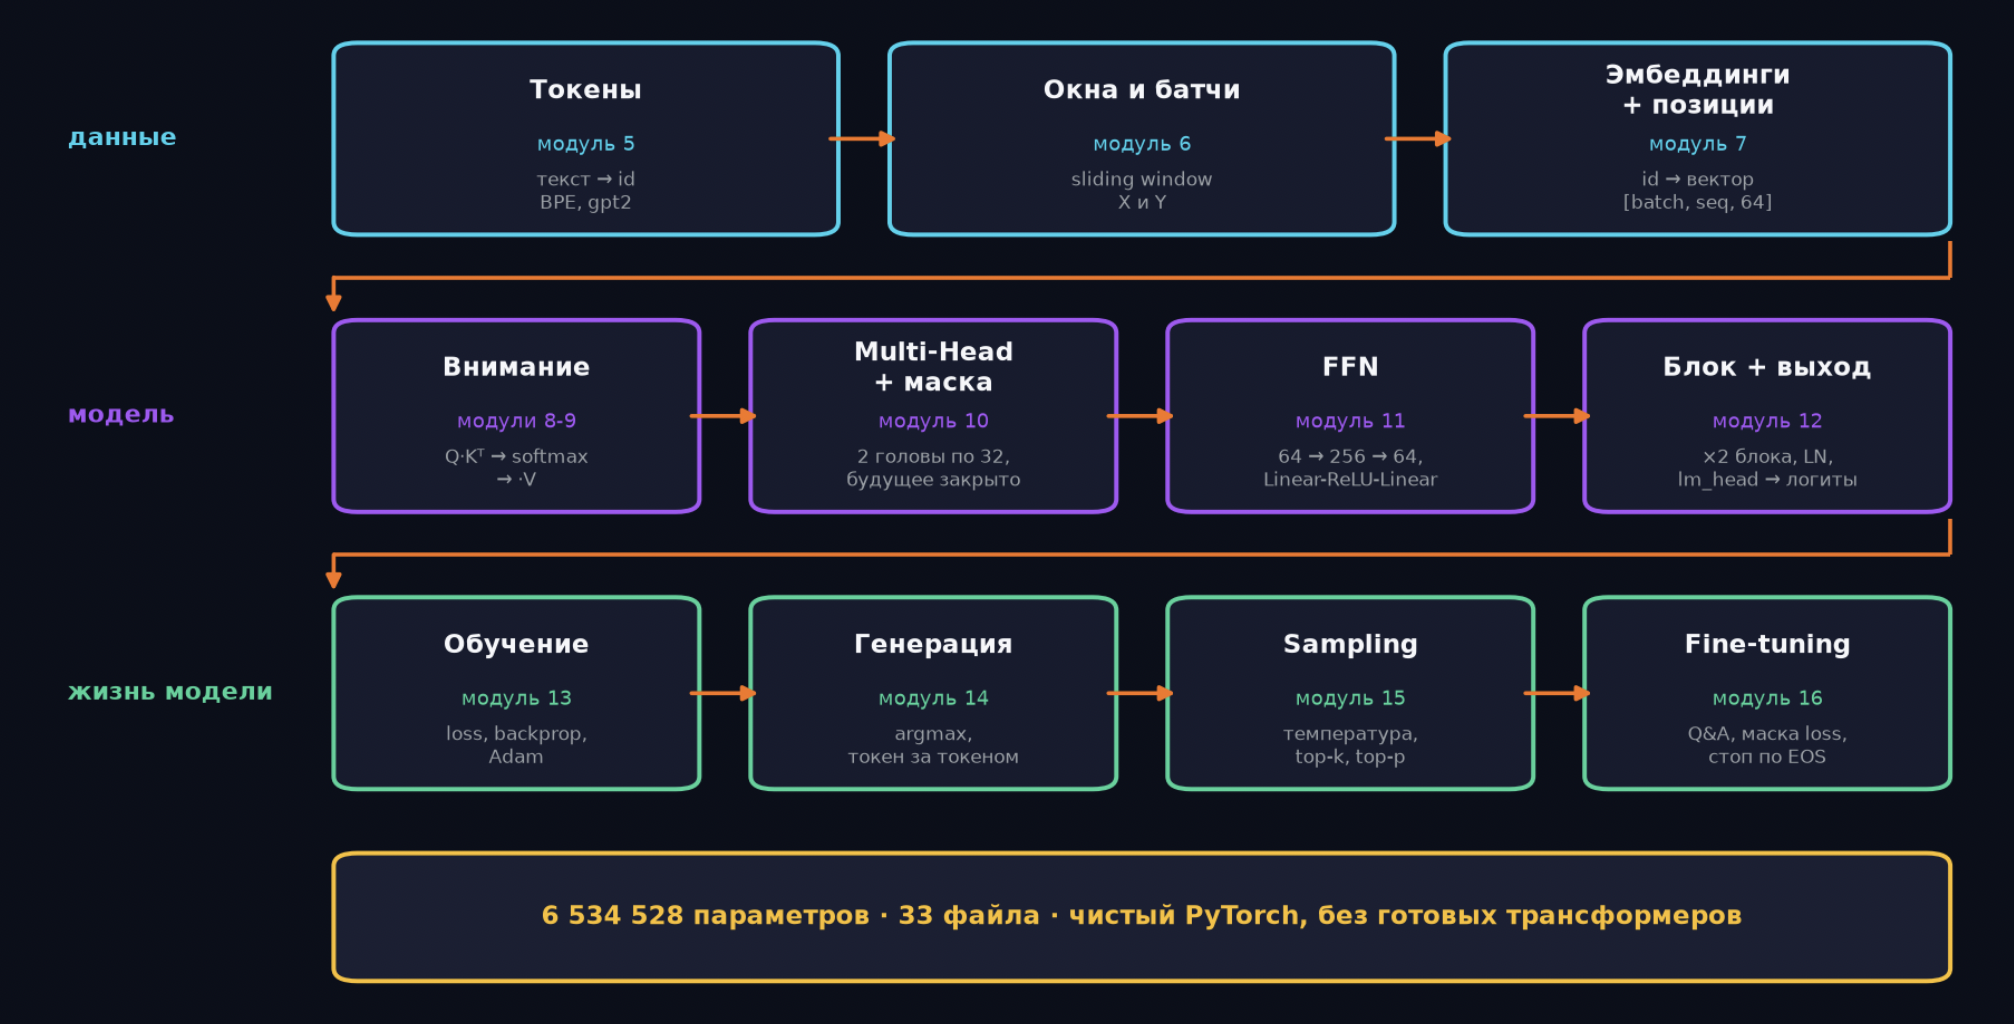